# YOLO Image Segmentation(이미지 분할)
## 객체 모양 그대로 영역(mask)을 찾음
- mask : 객체를 박스가 아니라 픽셀 단위로 표시한 영역.

In [9]:
!pip install ultralytics opencv-python

In [10]:
from cv2.gapi import mask
from cv2.cuda import resetDevice
import os, cv2, numpy as np
from ultralytics import YOLO

IMG_PATH = '/content/drive/MyDrive/yolo_imgs/image1.jpg'
OUT_DIR ='seg_out' # 출력 저장 폴더
os.makedirs(OUT_DIR, exist_ok=True) # 폴더 생성

im = cv2.imread(IMG_PATH)
assert im is not None, f"이미지 없음 \n{IMG_PATH}"

H, W = im.shape[:2] # 원본 이미지 높이/너비 얻기(마스크 리사이즈)

model = YOLO('yolo11n-seg.pt')
res = model(im)[0]
imsi = res
# print(imsi.boxes)   # 탐지 박스 정보
# print(imsi.masks)   # 세그멘테이션 마스크 정보
# masks.data(개별 마스크 이미지 데이터),
# masks.xy(객체 윤곽선 좌표), ...

# 원본 이미지 위에 바운딩박스 + 클래스 라벨 + 신뢰도를 하나의 마스크로 처리 - 검증용(YOLO가 직접 그려줌)
# 현재는 sanity check(기본 검증)를 함
cv2.imwrite(os.path.join(OUT_DIR, '00_anno.jpg'), res.plot())

# mask가 없다는건 세그멘테이션이 안돼었다는 뜻
if res.masks is None or len(res.masks.data) == 0:
  print('mask객체 없음')
  raise SystemExit


m_small = res.masks.data.cpu().numpy() # (N개, h, w) float 텐서를 numpy배열로 변환
# print(m_small) # 0 ~ 1 값
masks = np.stack([cv2.resize(m, (W, H), cv2.INTER_NEAREST) > 0.5 for m in m_small ], axis=0)
# cv2.INTER_NEAREST : 최근방 이웃 보간법 - 흐림방지용
# mask를 모아 (N, H, W) 배열로 만듦. -> mask는 최종적으로 N개의 bool stack이 됨.

# 세그 전 단계 mask preview
mask_union = (masks.any(axis=0).astype(np.uint8) * 255) # opencv에서 이미지 저장범위가 0 ~ 255
cv2.imwrite(os.path.join(OUT_DIR, '01_mask_preview.png'), mask_union) # 단일 마스크 흑백 이미지 저장


0: 416x640 2 persons, 433.1ms
Speed: 27.9ms preprocess, 433.1ms inference, 10.3ms postprocess per image at shape (1, 3, 416, 640)


True

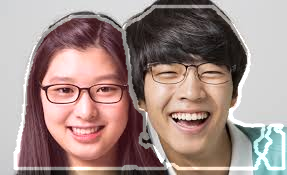

In [15]:
# 최종 세그멘테이션 : 컬러 오버레이 + 외곽선

def color(i):
  return ((37 * i) % 256, (17 * i) % 256, (91 * i) % 256)
  # return BGR - 색상을 튜플로 반환(고유 색상을 주기 위함, 마스크 외곽선을 위함)

final = im.copy() # 최종 합성용 캔버스
blend = np.zeros_like(im) # im 이미지와 크기가 같은 캔버스 - 0으로 채움

for i , m in enumerate(masks):
  blend[m] = color(i)

  # 마스크 영역에 고유색 채우기
  cnts, _ = cv2.findContours(
      m.astype(np.uint8) * 255, # 외곽선
      cv2.RETR_EXTERNAL,        # 가장 바깥쪽 외곽선
      cv2.CHAIN_APPROX_SIMPLE   # 꼭지점 단순화
  )

  # 복사된 원본이미지 외곽선만 얹어 경계 시각화 (OpenCV명령어 사용)
  cv2.drawContours(blend, cnts, -1, (255, 255, 255), 2, cv2.LINE_AA)
  # -1 : 모든 컨투어

  # 반투명 합성
final = cv2.addWeighted(final, 1.0, blend, 0.45, 0.0)

cv2.imwrite(os.path.join(OUT_DIR, '02_final_seg.png'), final)
# colab 방법
from google.colab.patches import cv2_imshow
cv2_imshow(final)
# vscode 방식
# cv2.imshow('final seg', final)
# cv2.waitKey(0)
# cv2.destroyAllWindows()
